In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("../data/cleaned/googleplaystore_cleaned.csv")

In [5]:
df.shape

(10841, 13)

### Category with highest number of applications

In [10]:
category_count = df["Category"].value_counts()
category_count.head(10)

Category
FAMILY             1972
GAME               1144
TOOLS               843
MEDICAL             463
BUSINESS            460
PRODUCTIVITY        424
PERSONALIZATION     392
COMMUNICATION       387
SPORTS              384
LIFESTYLE           382
Name: count, dtype: int64

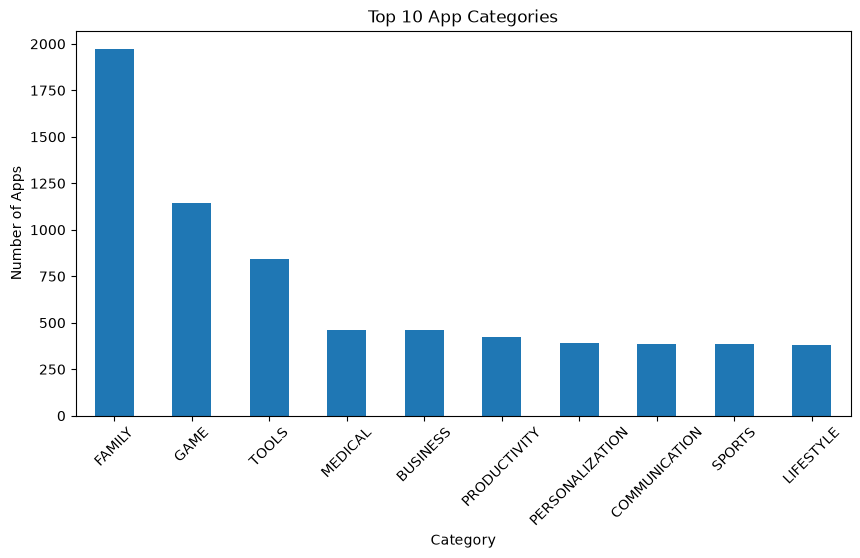

In [8]:
category_count.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.show()

### Insight
The Family, Game, and Tools categories contain the highest number of applications on the Google Play Store, indicating strong competition and high developer activity in these segments.

### Category with highest average rating

In [9]:
average_rating = df.groupby("Category")["Rating"].mean().sort_values(ascending=False)
average_rating.head(10)

Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.389032
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.346067
PERSONALIZATION         4.335987
PARENTING               4.300000
GAME                    4.286326
BEAUTY                  4.278571
HEALTH_AND_FITNESS      4.277104
Name: Rating, dtype: float64

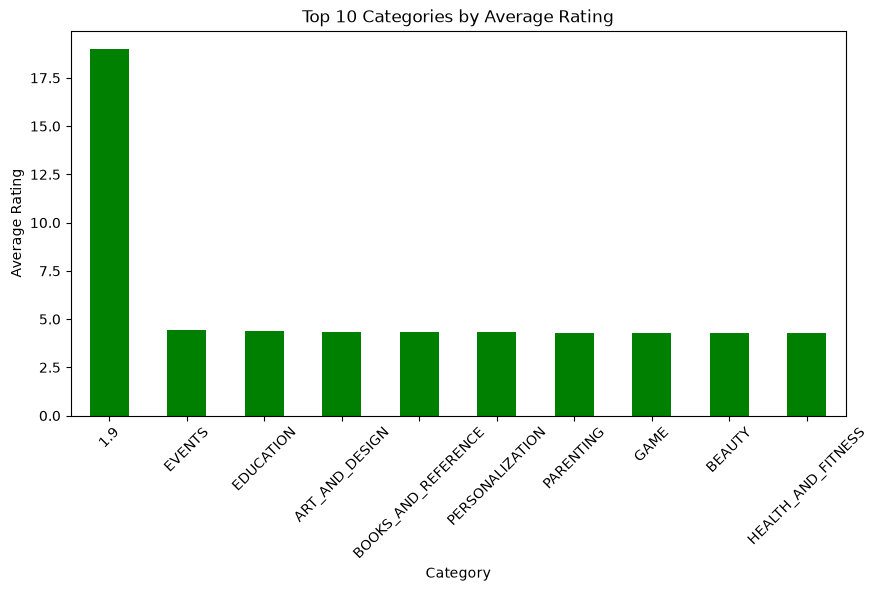

In [11]:
average_rating.head(10).plot(kind="bar", figsize=(10,5), color="green")
plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

### Insight
Categories such as Events, Education, and Art & Design receive higher average ratings, suggesting greater user satisfaction compared to other categories.

### Effect of app price on ratings

In [14]:
price_rating = df.groupby("Type")["Rating"].mean()
price_rating

Type
0       19.000000
Free     4.186203
Paid     4.266615
Name: Rating, dtype: float64

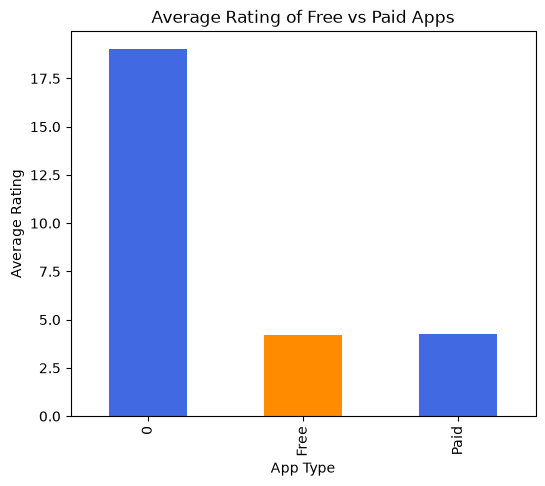

In [15]:
price_rating.plot(
    kind="bar",
    figsize=(6,5),
    color=["royalblue", "darkorange"]
)
plt.title("Average Rating of Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Average Rating")
plt.show()

### Insight
Insight: Paid apps generally have slightly higher average ratings than free apps, which may indicate better user experience or more specialized features. However, free apps dominate the overall market due to their accessibility.

### Distribution of Free vs Paid apps

In [16]:
app_type = df["Type"].value_counts()
app_type

Type
Free    10039
Paid      800
0           1
Name: count, dtype: int64

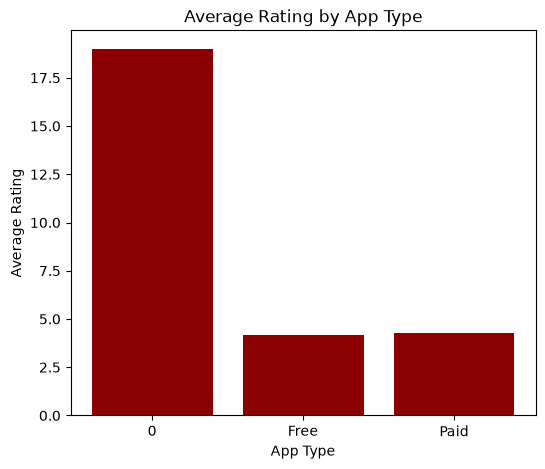

In [47]:
plt.figure(figsize=(6,5))
plt.bar(price_rating.index,
        price_rating.values,
        color="darkred")
plt.title("Average Rating by App Type")
plt.xlabel("App Type")
plt.ylabel("Average Rating")
plt.show()

### Insight
The Google Play Store is dominated by free applications, while paid apps represent only a small portion of the market. This indicates that developers primarily rely on free distribution models, often supported by advertisements or in-app purchases.

### Top 10 most Intalled Apps

In [42]:
top_apps = (
    df.groupby("App")["Installs"]
      .max()
      .sort_values(ascending=False)
      .head(10)
)
top_apps

App
Life Made WI-Fi Touchscreen Photo Frame            Free
Clean Master- Space Cleaner & Antivirus    500,000,000+
Facebook Lite                              500,000,000+
Cloud Print                                500,000,000+
Dropbox                                    500,000,000+
imo free video calls and chat              500,000,000+
MX Player                                  500,000,000+
Candy Crush Saga                           500,000,000+
LINE: Free Calls & Messages                500,000,000+
Pou                                        500,000,000+
Name: Installs, dtype: str

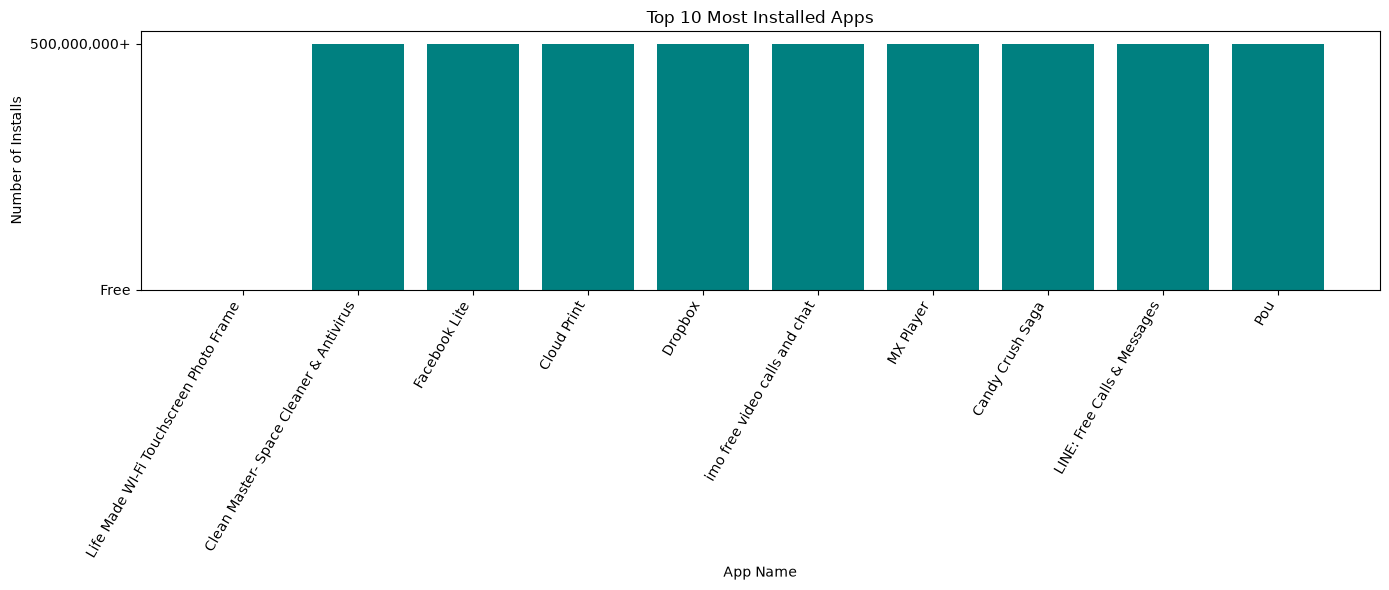

In [45]:
plt.figure(figsize=(14,6))
plt.bar(
    top_apps.index,
    top_apps.values,
    color="teal"
)
plt.title("Top 10 Most Installed Apps")
plt.xlabel("App Name")
plt.ylabel("Number of Installs")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### Insights
Popular applications from well-known companies dominate the highest installation counts. Strong brand recognition and broad user demand play a significant role in driving app downloads.

### Most common Content Rating

In [35]:
content_rating = df["Content Rating"].value_counts()
content_rating

Content Rating
Everyone           8714
Teen               1208
Mature 17+          499
Everyone 10+        414
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

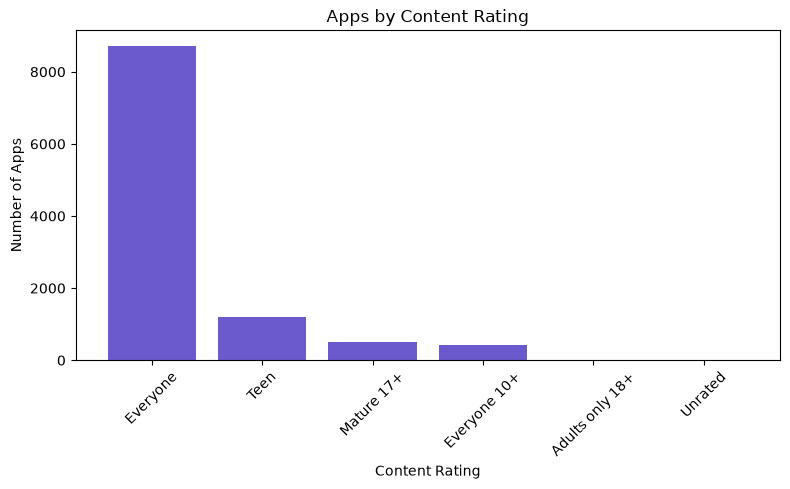

In [49]:
plt.figure(figsize=(8,5))
plt.bar(content_rating.index,
        content_rating.values,
        color="slateblue")
plt.title("Apps by Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insights
Most applications are designed for a general audience, with Everyone being the most common content rating. This suggests that developers primarily target a broad user base to maximize reach and downloads.